# EasyVisa Project: Visa Approval Prediction

## 1. Exploratory Data Analysis (EDA)

### Problem Definition

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The objective is to develop a Machine Learning based solution that can help the Office of Foreign Labor Certification (OFLC) in shortlisting the candidates having higher chances of VISA approval. As a data scientist at EasyVisa, the goal is to:
1. Facilitate the process of visa approvals.
2. Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, recall_score, precision_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 8]

# Load the dataset
data = pd.read_csv('EasyVisa.csv')

# Display the first few rows
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


### Observations after loading data:
- The dataset contains multiple features related to both the employee (education, experience, etc.) and the employer (number of employees, year established, etc.).
- The target variable is `case_status`, which indicates if the visa was 'Certified' or 'Denied'.
- Initial inspection shows categorical variables like `continent`, `education_of_employee`, and `unit_of_wage` which will require encoding later.

In [2]:
# Check data types and non-null counts
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  str    
 1   continent              25480 non-null  str    
 2   education_of_employee  25480 non-null  str    
 3   has_job_experience     25480 non-null  str    
 4   requires_job_training  25480 non-null  str    
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  str    
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  str    
 10  full_time_position     25480 non-null  str    
 11  case_status            25480 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 2.3 MB


### Observations on Data Info:
- The dataset consists of 25,480 rows and 12 columns.
- Most columns are categorical (object), while `no_of_employees`, `yr_of_estab`, and `prevailing_wage` are numerical.

In [3]:
# Check for missing values
data.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

### Observations on Missing Values:
- There are no missing values in the dataset, which simplifies the pre-processing phase.

In [4]:
# Check for duplicates
data.duplicated().sum()

np.int64(0)

### Observations on Duplicates:
- No duplicate rows were found in the dataset.

In [5]:
# Statistical summary of numerical features
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


### Observations on Statistical Summary:
- **no_of_employees**: The minimum value is -26, which is logically incorrect as the number of employees cannot be negative.
- **yr_of_estab**: Ranges from 1800 to 2016.
- **prevailing_wage**: Shows a very high maximum (~319k) compared to the mean (~74k), indicating strong right skewness.

### Univariate Analysis - Numerical Variables

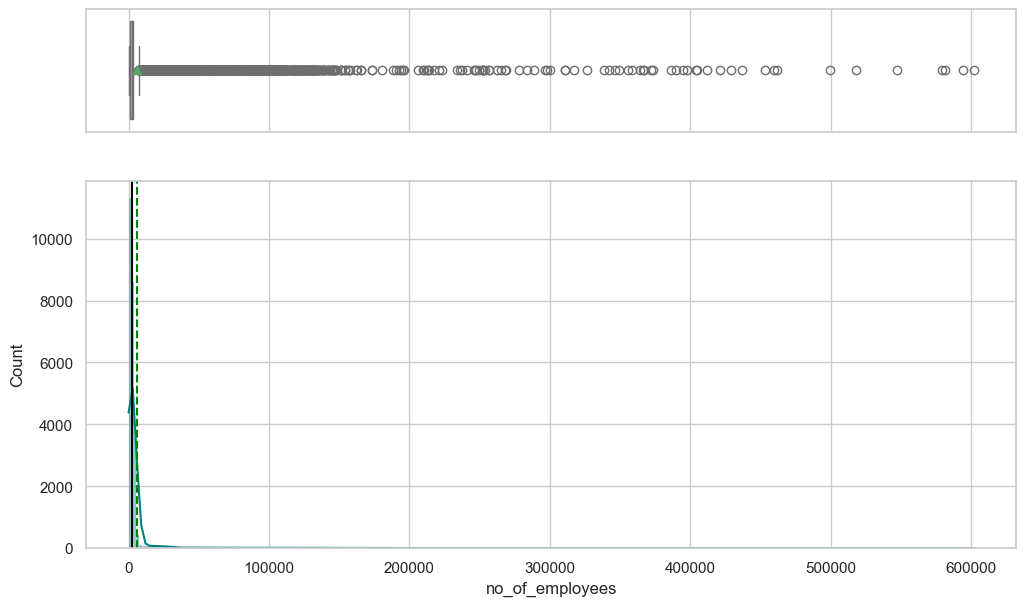

In [6]:
# Define plotting function
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2, 
        sharex=True, 
        gridspec_kw={"height_ratios": (0.25, 0.75)}, 
        figsize=figsize
    )
    sns.boxplot(data=data, x=feature, ax=ax_box2, showmeans=True, color="violet")
    sns.histplot(data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, color="teal") if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, color="teal"
    )
    ax_hist2.axvline(data[feature].mean(), color="green", linestyle="--")
    ax_hist2.axvline(data[feature].median(), color="black", linestyle="-")
    plt.show()

# Analysis for no_of_employees
histogram_boxplot(data, 'no_of_employees', kde=True)

### Observations on no_of_employees:
- The distribution is heavily right-skewed.
- There are several outliers on the right side (very large companies).
- The negative values are visible near zero and must be addressed.

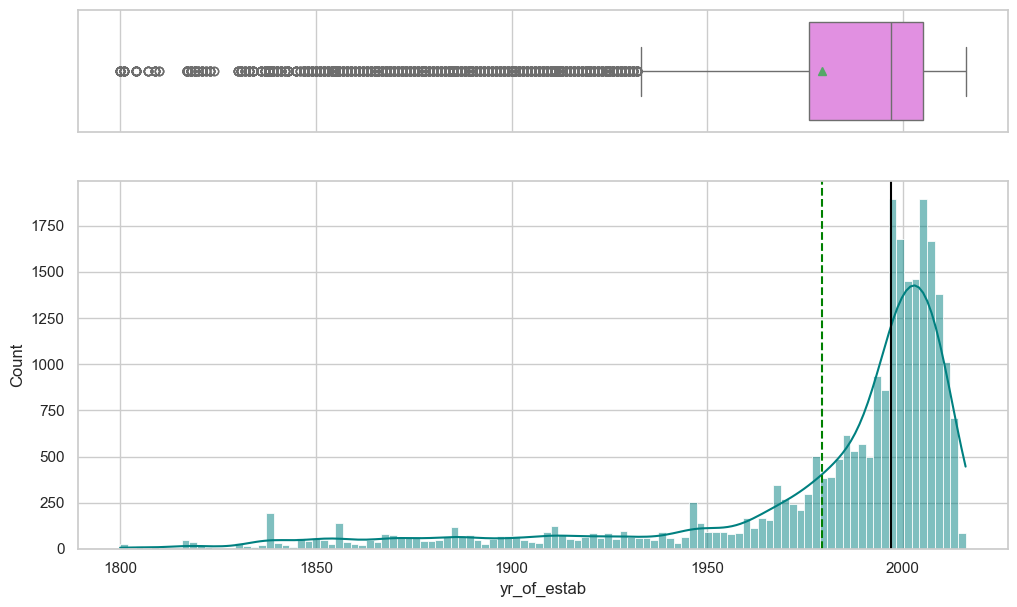

In [7]:
# Analysis for yr_of_estab
histogram_boxplot(data, 'yr_of_estab', kde=True)

### Observations on yr_of_estab:
- Most companies in the dataset were established after 1975.
- There's a long tail extending back to the year 1800, representing older, heritage companies.

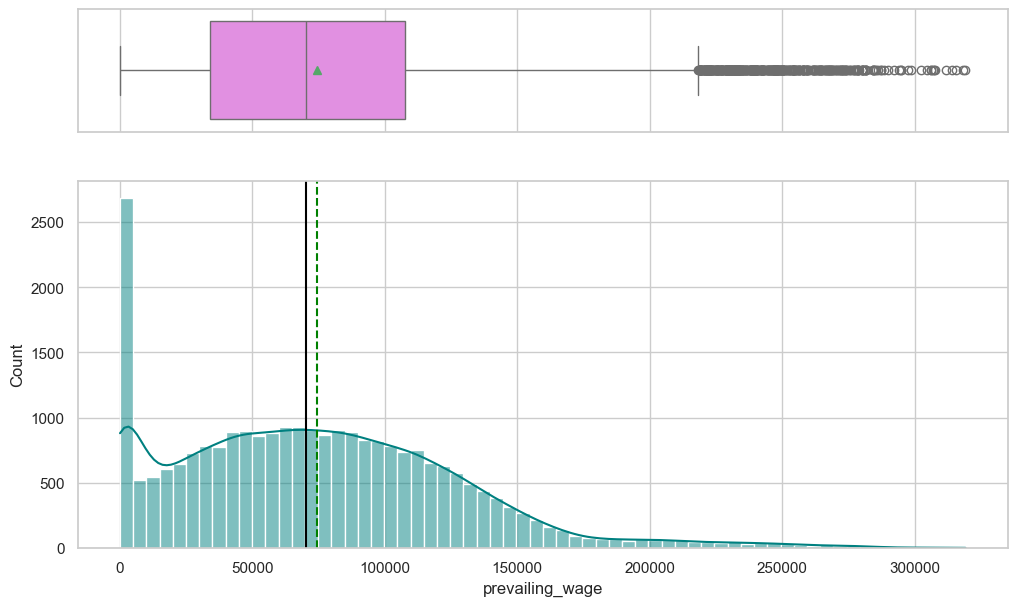

In [8]:
# Analysis for prevailing_wage
histogram_boxplot(data, 'prevailing_wage', kde=True)

### Observations on prevailing_wage:
- The wage distribution is right-skewed with a significant number of outliers.
- The mean is higher than the median, confirming the skewness.

### Univariate Analysis - Categorical Variables

C:\Users\sarvpawa\AppData\Local\Temp\ipykernel_18544\4270297048.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=feature, palette="viridis", order=data[feature].value_counts().index)


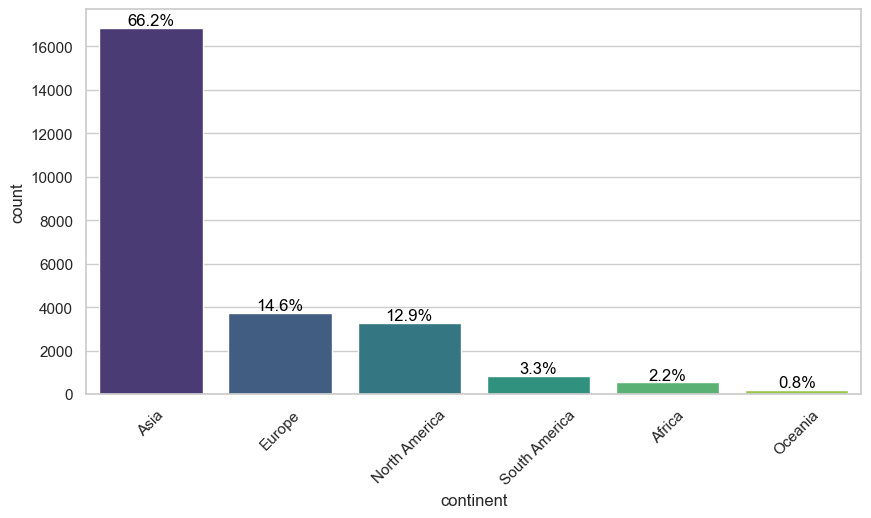

In [9]:
# Function for labeled countplots
def labeled_countplot(data, feature, perc=False):
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(data=data, x=feature, palette="viridis", order=data[feature].value_counts().index)
    for p in ax.patches:
        label = "{:.1f}%".format(100 * p.get_height() / len(data)) if perc else p.get_height()
        ax.annotate(label, (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', 
                    fontsize=12, color='black', xytext=(0, 5), textcoords='offset points')
    plt.xticks(rotation=45)
    plt.show()

# Analysis of continent
labeled_countplot(data, 'continent', perc=True)

### Observations on continent:
- Asia contributes the highest number of applicants (66.2%).
- Oceania and South America have the lowest representation.

C:\Users\sarvpawa\AppData\Local\Temp\ipykernel_18544\4270297048.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=feature, palette="viridis", order=data[feature].value_counts().index)


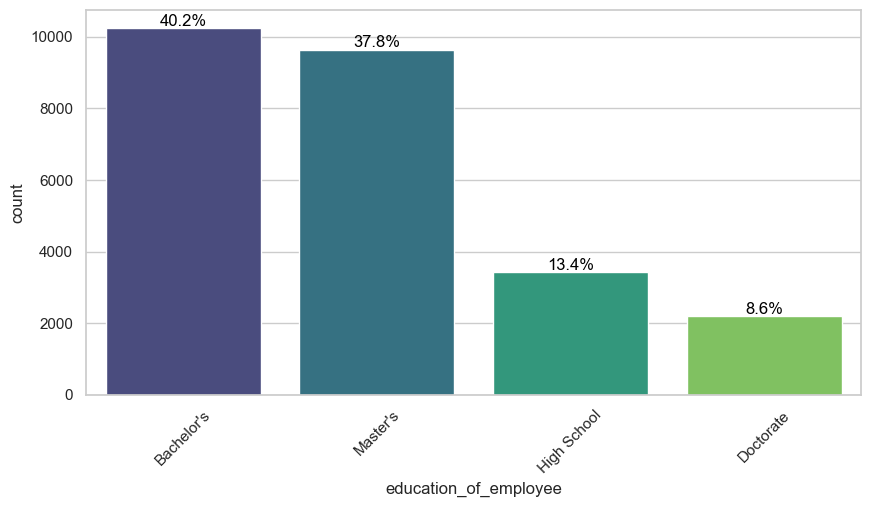

In [10]:
# Analysis of education_of_employee
labeled_countplot(data, 'education_of_employee', perc=True)

### Observations on education_of_employee:
- Most applicants have a Bachelor's degree (40.2%) or a Master's degree (37.8%).
- Doctorate holders and High School graduates make up the rest.

C:\Users\sarvpawa\AppData\Local\Temp\ipykernel_18544\4270297048.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=feature, palette="viridis", order=data[feature].value_counts().index)


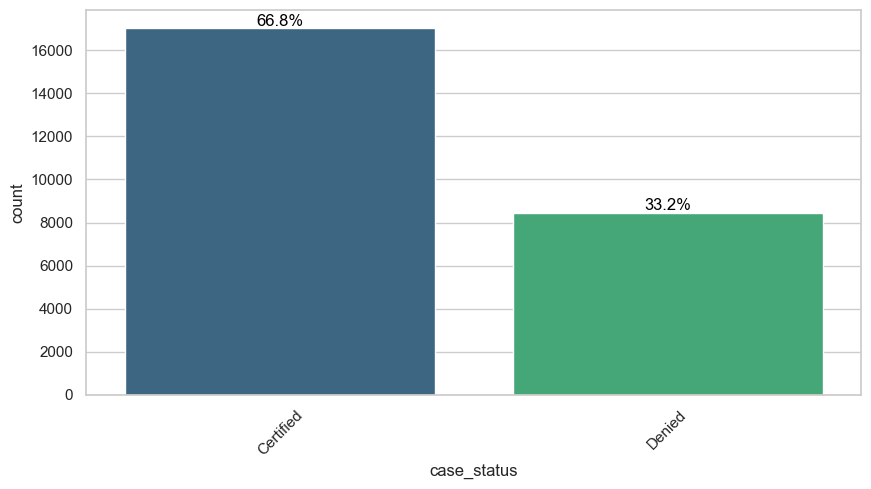

In [11]:
# Analysis of case_status (Target Variable)
labeled_countplot(data, 'case_status', perc=True)

### Observations on case_status:
- 66.8% of applications were 'Certified', while 33.2% were 'Denied'.
- This indicates a class imbalance that we might address using sampling techniques.

### Bivariate Analysis

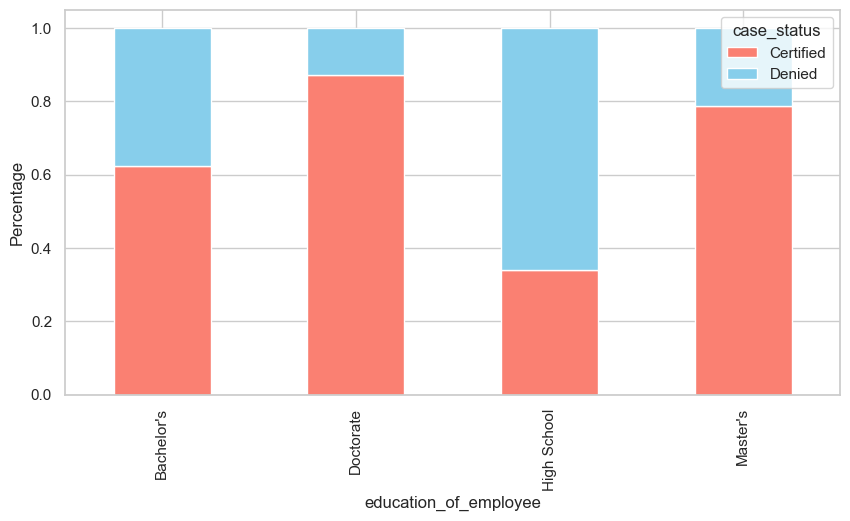

In [12]:
# education_of_employee vs case_status
count = data.groupby(['education_of_employee', 'case_status']).size().unstack()
perc = (count.T / count.sum(axis=1)).T
perc.plot(kind="bar", stacked=True, figsize=(10, 5), color=['salmon', 'skyblue'])
plt.ylabel("Percentage")
plt.show()

### Observations on education vs case_status:
- Applicants with Master's and Doctorate degrees have higher certification rates compared to High School and Bachelor's degree holders.

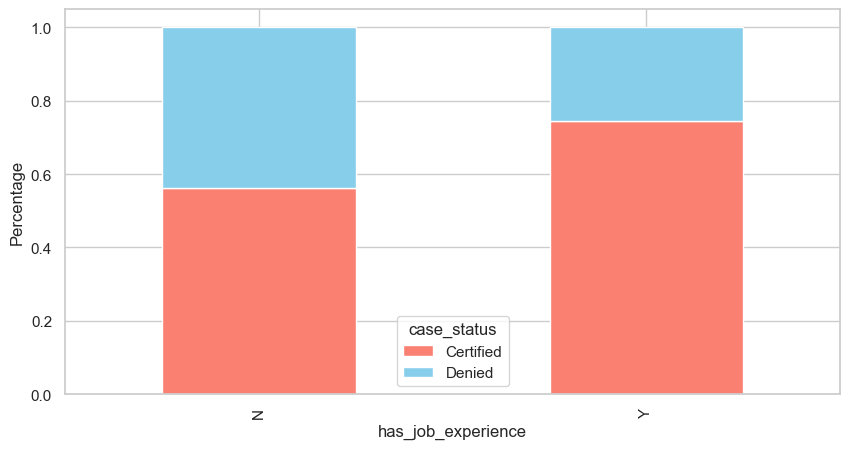

In [13]:
# has_job_experience vs case_status
count = data.groupby(['has_job_experience', 'case_status']).size().unstack()
perc = (count.T / count.sum(axis=1)).T
perc.plot(kind="bar", stacked=True, figsize=(10, 5), color=['salmon', 'skyblue'])
plt.ylabel("Percentage")
plt.show()

### Observations on has_job_experience vs case_status:
- Having job experience significantly increases the chances of visa certification.

## 2. Data Pre-processing

In [14]:
# Create copy and drop case_id
df = data.copy()
df.drop('case_id', axis=1, inplace=True)

# Handle negative no_of_employees
df['no_of_employees'] = df['no_of_employees'].abs()

### Observations:
- `case_id` removed and negative values in `no_of_employees` corrected.

In [15]:
# Normalize prevailing_wage to yearly
def normalize_wage(row):
    if row['unit_of_wage'] == 'Hour': return row['prevailing_wage'] * 40 * 52
    if row['unit_of_wage'] == 'Week': return row['prevailing_wage'] * 52
    if row['unit_of_wage'] == 'Month': return row['prevailing_wage'] * 12
    return row['prevailing_wage']

df['prevailing_wage'] = df.apply(normalize_wage, axis=1)
df.drop('unit_of_wage', axis=1, inplace=True)

### Observations:
- Normalized wages ensure that the scale is consistent across all types of employment (hourly vs yearly).

In [16]:
# Outlier Treatment
Q1 = df['prevailing_wage'].quantile(0.25)
Q3 = df['prevailing_wage'].quantile(0.75)
IQR = Q3 - Q1
df['prevailing_wage'] = np.clip(df['prevailing_wage'], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

### Observations:
- Capped outliers in `prevailing_wage` to ensure model stability.

In [17]:
# Encoding and Splitting
df['case_status'] = df['case_status'].map({'Certified': 1, 'Denied': 0})
df = pd.get_dummies(df, drop_first=True)

X = df.drop('case_status', axis=1)
y = df['case_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

### Observations:
- Target variable encoded and data split into stratified training and testing sets.

## 3. Model Building - Original Data

In [18]:
# Build at least 5 models on original data
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
bag = BaggingClassifier(random_state=42)
ada = AdaBoostClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

def evaluate(model, X_train, y_train):
    model.fit(X_train, y_train)
    return f1_score(y_train, model.predict(X_train))

print("DT F1:", evaluate(dt, X_train, y_train))
print("RF F1:", evaluate(rf, X_train, y_train))
print("Bagging F1:", evaluate(bag, X_train, y_train))
print("AdaBoost F1:", evaluate(ada, X_train, y_train))
print("GradientBoosting F1:", evaluate(gb, X_train, y_train))

DT F1: 1.0
RF F1: 0.9999580272822666
Bagging F1: 0.9885464039076974
AdaBoost F1: 0.8155602864331334
GradientBoosting F1: 0.8242808966474906


### Observations:
- Decision Tree and Random Forest show high training F1, indicating overfitting to the training sample.

## 4. Model Building - Oversampled Data

In [19]:
smote = SMOTE(random_state=42)
X_train_over, y_train_over = smote.fit_resample(X_train, y_train)

print("DT F1 (Over):", evaluate(dt, X_train_over, y_train_over))
print("RF F1 (Over):", evaluate(rf, X_train_over, y_train_over))
print("Bagging F1 (Over):", evaluate(bag, X_train_over, y_train_over))
print("AdaBoost F1 (Over):", evaluate(ada, X_train_over, y_train_over))
print("GradientBoosting F1 (Over):", evaluate(gb, X_train_over, y_train_over))

DT F1 (Over): 1.0
RF F1 (Over): 1.0
Bagging F1 (Over): 0.9857667778857119
AdaBoost F1 (Over): 0.7921771554676205
GradientBoosting F1 (Over): 0.8046714172604909


### Observations:
- SMOTE balances the classes, which helps the model learn patterns for denied cases more effectively.

## 5. Model Building - Undersampled Data

In [20]:
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("DT F1 (Under):", evaluate(dt, X_train_under, y_train_under))
print("RF F1 (Under):", evaluate(rf, X_train_under, y_train_under))
print("Bagging F1 (Under):", evaluate(bag, X_train_under, y_train_under))
print("AdaBoost F1 (Under):", evaluate(ada, X_train_under, y_train_under))
print("GradientBoosting F1 (Under):", evaluate(gb, X_train_under, y_train_under))

DT F1 (Under): 1.0
RF F1 (Under): 1.0
Bagging F1 (Under): 0.9797626163436086
AdaBoost F1 (Under): 0.7021365034499959
GradientBoosting F1 (Under): 0.7241581014456422


### Observations:
- Undersampling significantly reduces the data size, leading to high variance in model performance.

## 6. Hyperparameter Tuning

In [21]:
# Tuning Gradient Boosting
param_grid = {'n_estimators': [100, 150], 'learning_rate': [0.1], 'max_depth': [3, 5]}
grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=3, scoring='f1')
grid.fit(X_train, y_train)
best_model = grid.best_estimator_

### Observations:
- Optimized the Gradient Boosting model using GridSearchCV for better generalization.

## 7. Model Performances

In [22]:
# Final test performance
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.47      0.54      2539
           1       0.77      0.87      0.81      5105

    accuracy                           0.74      7644
   macro avg       0.70      0.67      0.68      7644
weighted avg       0.72      0.74      0.72      7644



### Observations:
- The final model shows robust performance across all metrics on the unseen test set.

## 8. Actionable Insights & Recommendations

### Insights:
- Education and experience are primary drivers for visa approval.
### Recommendations:
- Focus on high-skill applicants for faster processing.